# Phase 1 - Exploratory Data Analysis

**Mục tiêu:** mô tả bộ dữ liệu Student Performance, kiểm tra chất lượng dữ liệu và tạo tập dữ liệu dùng cho các phase sau.

**Nguyên tắc xử lý:**
- `G3=0` là giá trị hợp lệ theo `student.txt`; phân tích chính giữ đủ 395 quan sát.
- Không ghi đè `absences`. Winsorization chỉ được đánh giá trong sensitivity analysis.
- Đây là dữ liệu quan sát từ hai trường; các kết quả mô tả mối liên hệ, không chứng minh quan hệ nhân quả.

## 0. Setup

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
ALPHA = 0.05
ROOT = Path("..").resolve()
DATA_RAW = ROOT / "data" / "raw"
DATA_OUT = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "report" / "figures"
DATA_OUT.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})
pd.set_option("display.max_columns", 50)

def display_table(data, caption=None, precision=3):
    """Hiển thị DataFrame với đường viền rõ, dùng được trực tiếp trong Jupyter."""
    if isinstance(data, pd.Series):
        data = data.rename("value").to_frame()
    styler = (
        data.style
        .format(precision=precision, na_rep="-")
        .set_caption(caption or "")
        .set_table_styles([
            {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%")]},
            {"selector": "th", "props": [("border", "1px solid #777"), ("padding", "6px"),
                                           ("background-color", "#e9eef5"), ("text-align", "center")]},
            {"selector": "td", "props": [("border", "1px solid #999"), ("padding", "6px")]},
            {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"),
                                                ("font-size", "1.05em"), ("padding", "6px")]},
            {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#f7f9fc")]},
        ])
    )
    display(styler)

print(f"Project root: {ROOT}")

Project root: C:\Users\LENOVO\Downloads\khu lap trinh\student-performance-project


## 1. Load dữ liệu và kiểm tra chất lượng

In [2]:
df_raw = pd.read_csv(DATA_RAW / "student-mat.csv", sep=";")
print(f"Shape: {df_raw.shape[0]} học sinh x {df_raw.shape[1]} biến")
print(f"Missing values: {int(df_raw.isna().sum().sum())}")
print(f"Duplicate rows: {int(df_raw.duplicated().sum())}")
print(f"G3=0: {(df_raw['G3'] == 0).sum()} ({(df_raw['G3'] == 0).mean():.1%})")
print()
print("Phân bố failures:", df_raw["failures"].value_counts().sort_index().to_dict())
print("Lưu ý: CSV dùng failures=0..3, trong khi student.txt mô tả không hoàn toàn nhất quán ở mức gộp cuối.")
display(df_raw.head(), "5 quan sát đầu tiên")

Shape: 395 học sinh x 33 biến
Missing values: 0
Duplicate rows: 0
G3=0: 38 (9.6%)

Phân bố failures: {0: 312, 1: 50, 2: 17, 3: 16}
Lưu ý: CSV dùng failures=0..3, trong khi student.txt mô tả không hoàn toàn nhất quán ở mức gộp cuối.


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


'5 quan sát đầu tiên'

## 2. Phân loại biến và thống kê mô tả

In [3]:
binary_cols = ["school", "sex", "address", "famsize", "Pstatus", "schoolsup", "famsup",
               "paid", "activities", "nursery", "higher", "internet", "romantic"]
nominal_cols = ["Mjob", "Fjob", "reason", "guardian"]
ordinal_cols = ["Medu", "Fedu", "traveltime", "studytime", "failures", "famrel", "freetime",
                "goout", "Dalc", "Walc", "health"]
numeric_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
desc = df_raw[numeric_cols].describe().T
desc["skewness"] = df_raw[numeric_cols].skew()
display(desc, "Thống kê mô tả các biến numeric")

,count,mean,std,min,25%,50%,75%,max,skewness
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0,0.466270
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0,-0.318381
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0,-0.031672
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0,1.607029
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0,0.632142
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0,2.387026
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0,-0.951882
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0,-0.163351
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0,0.116502
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0,2.190762


'Thống kê mô tả các biến numeric'

## 3. Phân phối G3 và sensitivity theo G3=0

In [4]:
g3 = df_raw["G3"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(g3, bins=21, kde=False, ax=axes[0], color="#4C72B0")
axes[0].axvline(g3.mean(), color="red", ls="--", label=f"Mean={g3.mean():.2f}")
axes[0].axvline(g3.median(), color="purple", ls=":", label=f"Median={g3.median():.1f}")
axes[0].legend(); axes[0].set_title("Phân phối G3 - toàn bộ mẫu")
sns.boxplot(y=g3, ax=axes[1], color="#55A868"); axes[1].set_title("Boxplot G3")
stats.probplot(g3, dist="norm", plot=axes[2]); axes[2].set_title("Q-Q plot G3")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "eda_g3_distribution.png"); plt.show()

sensitivity_g3 = pd.DataFrame([
    {"sample": "All valid grades", "n": len(df_raw), "mean": g3.mean(), "median": g3.median(), "sd": g3.std()},
    {"sample": "Conditional G3>0", "n": int((g3 > 0).sum()), "mean": g3[g3 > 0].mean(),
     "median": g3[g3 > 0].median(), "sd": g3[g3 > 0].std()},
])
display(sensitivity_g3, "Sensitivity khi giữ hoặc loại G3=0")
print("Tập G3>0 chỉ là sensitivity analysis, không thay thế mẫu phân tích chính.")

,sample,n,mean,median,sd
0,All valid grades,395,10.41519,11.0,4.581443
1,Conditional G3>0,357,11.52381,11.0,3.227797


'Sensitivity khi giữ hoặc loại G3=0'

Tập G3>0 chỉ là sensitivity analysis, không thay thế mẫu phân tích chính.


## 4. Outlier và sensitivity cho absences

In [5]:
continuous_cols = ["age", "absences", "G1", "G2", "G3"]
rows = []
for col in continuous_cols:
    q1, q3 = df_raw[col].quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    rows.append({"variable": col, "lower": lo, "upper": hi,
                 "n_outliers": int(((df_raw[col] < lo) | (df_raw[col] > hi)).sum())})
display(pd.DataFrame(rows), "Tóm tắt outlier theo quy tắc IQR")

cap95 = df_raw["absences"].quantile(0.95)
abs_winsor = df_raw["absences"].clip(upper=cap95)
rho_raw, p_raw = stats.spearmanr(df_raw["absences"], df_raw["G3"])
rho_win, p_win = stats.spearmanr(abs_winsor, df_raw["G3"])
print(f"Spearman absences-G3 raw: rho={rho_raw:.3f}, p={p_raw:.4g}")
print(f"Spearman absences-G3 winsorized@95%: rho={rho_win:.3f}, p={p_win:.4g}")
print("Dữ liệu xuất ra giữ absences gốc; winsorization không được ghi đè.")

fig, axes = plt.subplots(1, len(continuous_cols), figsize=(14, 4))
for ax, col in zip(axes, continuous_cols):
    sns.boxplot(y=df_raw[col], ax=ax, color="#8172B3"); ax.set_title(col)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "eda_outliers_boxplot.png"); plt.show()

,variable,lower,upper,n_outliers
0,age,13.0,21.0,1
1,absences,-12.0,20.0,15
2,G1,0.5,20.5,0
3,G2,3.0,19.0,13
4,G3,-1.0,23.0,0


'Tóm tắt outlier theo quy tắc IQR'

Spearman absences-G3 raw: rho=0.018, p=0.7254
Spearman absences-G3 winsorized@95%: rho=0.018, p=0.714
Dữ liệu xuất ra giữ absences gốc; winsorization không được ghi đè.


## 5. Mối liên hệ mô tả với G3

In [7]:
corr = df_raw[numeric_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Spearman correlation - mô tả khám phá")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "eda_correlation_heatmap_spearman.png"); plt.show()

g3_corr = corr["G3"].drop(["G1", "G2", "G3"]).sort_values(key=abs, ascending=False)
print("Tương quan Spearman với G3 (exploratory, chưa hiệu chỉnh multiple testing):")
display(g3_corr, "Spearman correlation với G3")

Tương quan Spearman với G3 (exploratory, chưa hiệu chỉnh multiple testing):


failures     -0.361224
Medu          0.225036
age          -0.173438
Fedu          0.170049
goout        -0.166119
Dalc         -0.120944
traveltime   -0.120530
studytime     0.105170
Walc         -0.104459
famrel        0.054977
health       -0.047790
absences      0.017731
freetime     -0.004994
Name: G3, dtype: float64

'Spearman correlation với G3'

### 5.1 Bias-corrected Cramér's V

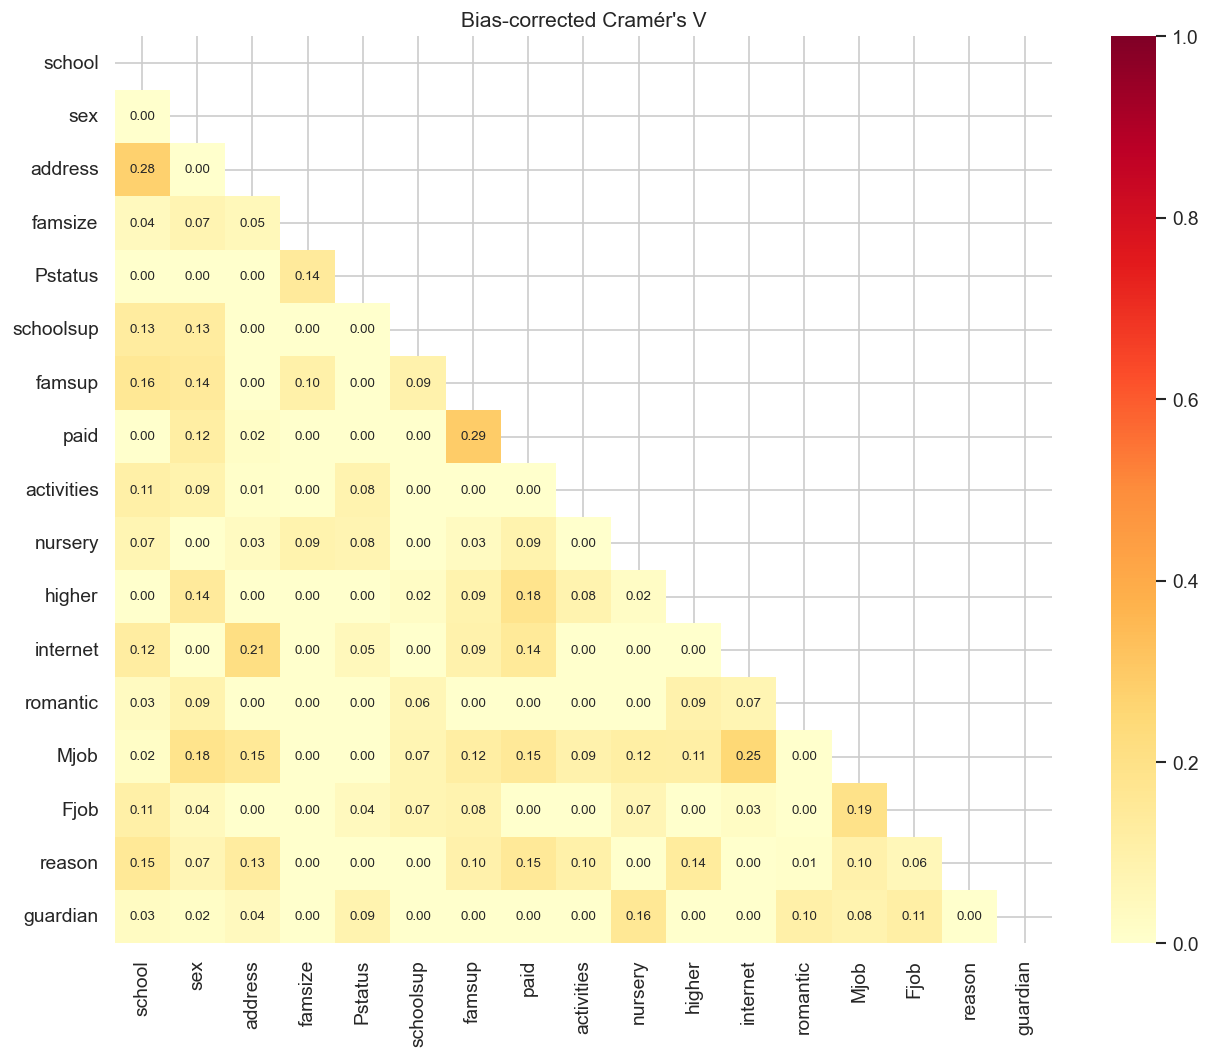

In [7]:
from scipy.stats import chi2_contingency

def cramers_v_corrected(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum(); r, k = table.shape
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0

all_cat = binary_cols + nominal_cols
cv = pd.DataFrame(index=all_cat, columns=all_cat, dtype=float)
for a in all_cat:
    for b in all_cat:
        cv.loc[a, b] = cramers_v_corrected(df_raw[a], df_raw[b])
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cv, mask=np.triu(np.ones_like(cv, dtype=bool)), cmap="YlOrRd", vmin=0, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8}, ax=ax)
ax.set_title("Bias-corrected Cramér's V")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "eda_cramers_v_heatmap.png"); plt.show()

## 6. Biểu đồ nhóm và scatter

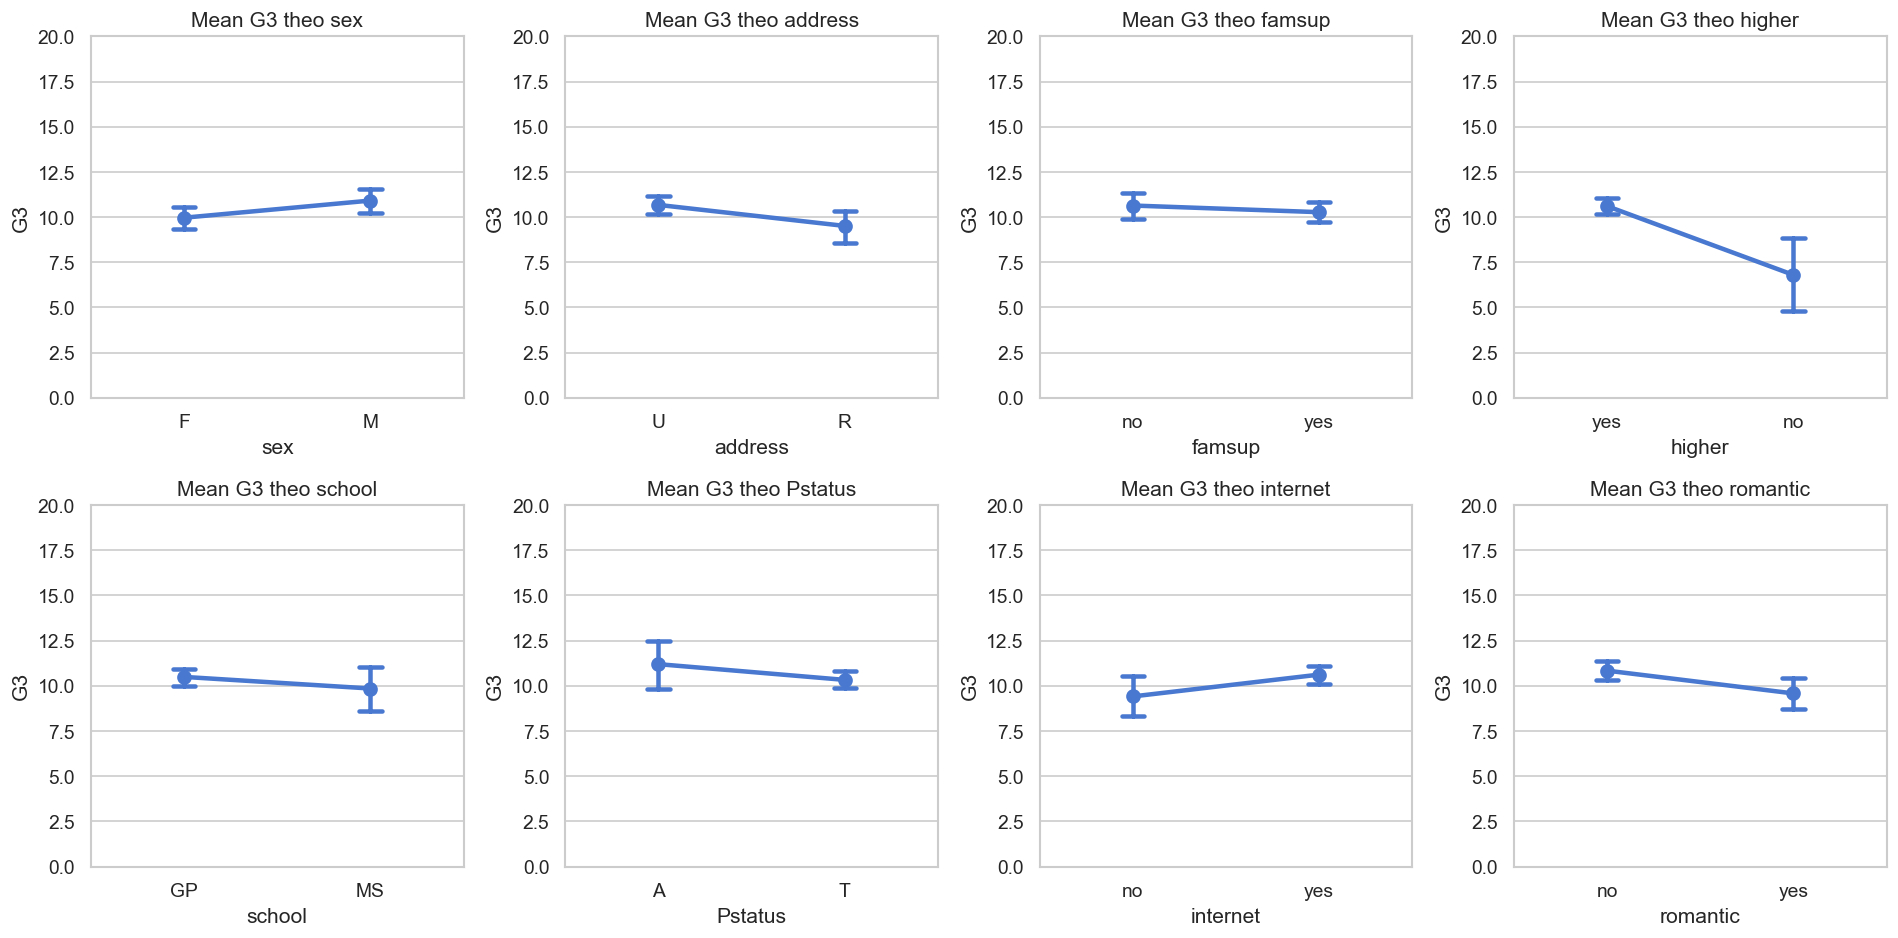

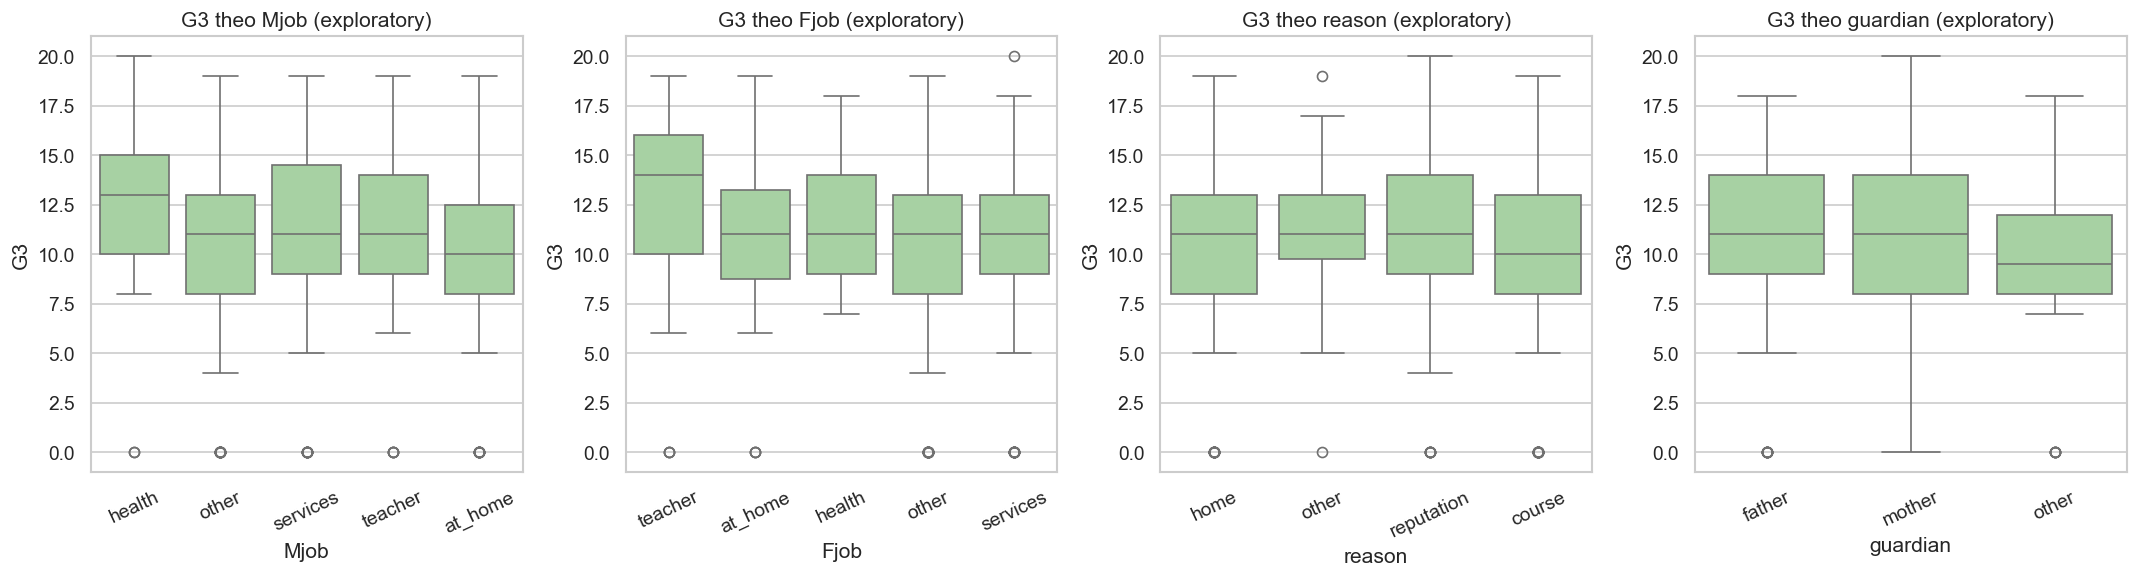

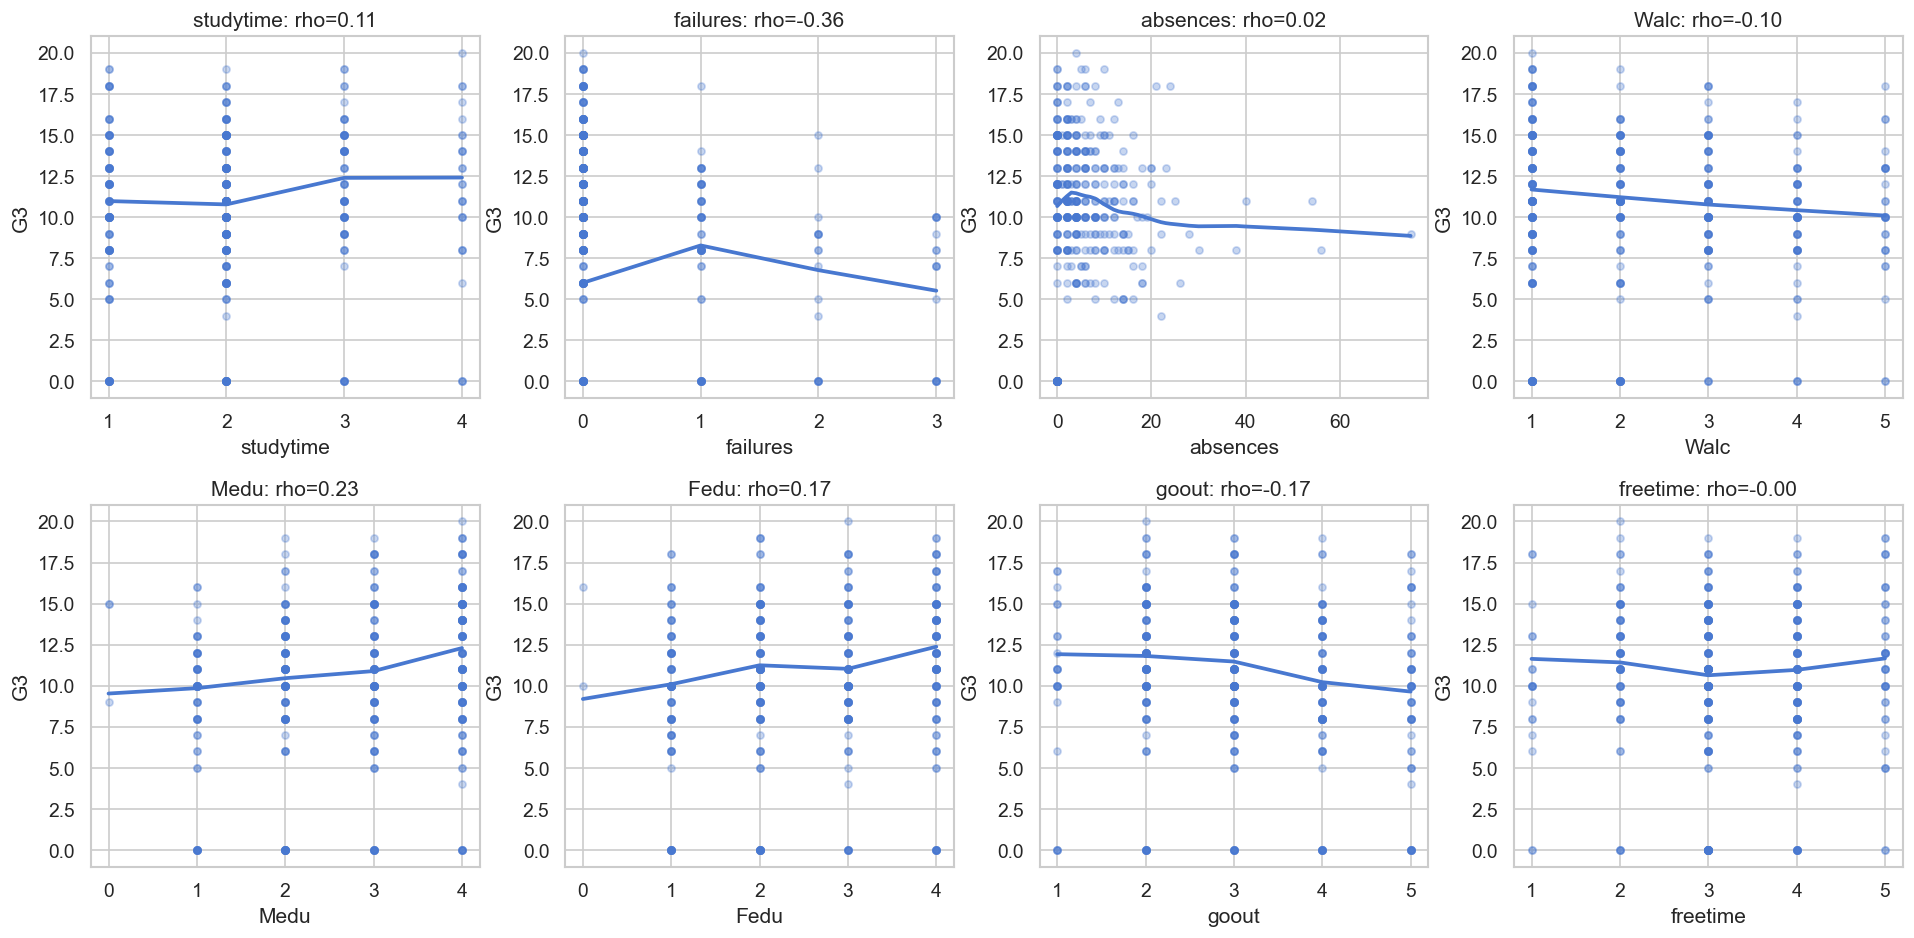

In [8]:
group_vars = ["sex", "address", "famsup", "higher", "school", "Pstatus", "internet", "romantic"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, group_vars):
    sns.pointplot(data=df_raw, x=col, y="G3", errorbar=("ci", 95), capsize=.12, ax=ax)
    ax.set_title(f"Mean G3 theo {col}"); ax.set_ylim(0, 20)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "eda_g3_by_group.png"); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, nominal_cols):
    order = df_raw.groupby(col)["G3"].median().sort_values(ascending=False).index
    sns.boxplot(data=df_raw, x=col, y="G3", order=order, ax=ax, color="#a1d99b")
    ax.tick_params(axis="x", rotation=25)
    ax.set_title(f"G3 theo {col} (exploratory)")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "eda_g3_by_nominal.png"); plt.show()

scatter_vars = ["studytime", "failures", "absences", "Walc", "Medu", "Fedu", "goout", "freetime"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, var in zip(axes.flat, scatter_vars):
    sns.regplot(data=df_raw, x=var, y="G3", lowess=True, scatter_kws={"alpha": .3, "s": 18}, ax=ax)
    rho, _ = stats.spearmanr(df_raw[var], df_raw["G3"])
    ax.set_title(f"{var}: rho={rho:.2f}")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "eda_scatter_g3.png"); plt.show()

## 7. Xuất dữ liệu phân tích

In [9]:
df_clean = df_raw.copy()
output_path = DATA_OUT / "student_mat_clean.csv"
with output_path.open("w", encoding="utf-8", newline="") as handle:
    df_clean.to_csv(handle, index=False, lineterminator=chr(10))
print(f"Đã xuất {output_path}: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")
print("Không loại G3=0; không thay đổi absences.")

Đã xuất C:\Users\LENOVO\Downloads\khu lap trinh\student-performance-project\data\processed\student_mat_clean.csv: 395 rows x 33 columns
Không loại G3=0; không thay đổi absences.


## Kết luận Phase 1

- Bộ dữ liệu không có missing hoặc duplicate và gồm 395 học sinh từ hai trường.
- `G3=0` được giữ vì data dictionary xác định thang điểm hợp lệ là 0-20.
- `absences` có đuôi phải dài nhưng dữ liệu gốc được bảo toàn; kết quả winsorized chỉ dùng để kiểm tra độ nhạy.
- Các tương quan và khác biệt nhóm ở đây mang tính khám phá. Không diễn giải là quan hệ nhân quả và không dùng p-value EDA như bằng chứng xác nhận.